# Análise de Resultados - PUMA FL
Este notebook processa as múltiplas simulações (runs) geradas pelo servidor e plota as curvas de performance comparando diferentes estratégias, exibindo o intervalo de confiança (desvio padrão).

In [28]:
# Caminho padrão para a pasta de resultados (SERVIDOR)
EXP_NAME = "fl_session_20260706_130842" # INSIRA O NOME DA PASTA DO SEU EXPERIMENTO AQUI (ex: fl_session_20260706_120400)
RESULTS_DIR = f"../results/{EXP_NAME}/"
# Caminho para a pasta de resultados locais (CLIENTES)


In [29]:
import os
import glob
import numpy as np
import h5py
import matplotlib.pyplot as plt
def load_strategy_results(dataset, strategy, paca=12, algo="FedALA", prune="withou_Prune", rank=8):
    if rank is not None:
        pattern = os.path.join(
            RESULTS_DIR,
            f"server_{dataset}_{strategy}_rank{rank}_paca{paca}_{prune}_{algo}_run*.h5"
        )
    else:
        pattern = os.path.join(
            RESULTS_DIR,
            f"server_{dataset}_{strategy}_paca{paca}_{prune}_{algo}_run*.h5"
        )
    files = glob.glob(pattern)
    
    if not files:
        print(f"⚠️ Nenhum arquivo de SERVIDOR encontrado para: {pattern}")
        return None
        
    print(f"✅ Encontrados {len(files)} arquivos de SERVIDOR para o padrão: {dataset}_{strategy}_paca{paca}_{prune}_{algo}")
    
    acc_runs, loss_runs, mb_runs, mb_bruto_runs, time_runs, params_runs, size_runs = [], [], [], [], [], [], []
    
    for f in files:
        with h5py.File(f, 'r') as hf:
            acc_runs.append(np.array(hf['rs_test_acc']))
            loss_runs.append(np.array(hf['rs_train_loss']))
            mb_runs.append(np.array(hf['sended_model_Mb']))
            mb_bruto_runs.append(np.array(hf['Sended_without_quant']))
            time_runs.append(np.array(hf['Round_time']))
            
            if 'Trainable_params' in hf:
                params_runs.append(np.array(hf['Trainable_params']))
            else:
                params_runs.append(np.zeros_like(np.array(hf['Round_time'])))
                
            if 'Model_size_per_round_Mb' in hf:
                size_runs.append(np.array(hf['Model_size_per_round_Mb']))
            else:
                size_runs.append(np.zeros_like(np.array(hf['Round_time'])))
            
    return {
        'acc_mean': np.mean(acc_runs, axis=0), 'acc_std': np.std(acc_runs, axis=0),
        'loss_mean': np.mean(loss_runs, axis=0), 'loss_std': np.std(loss_runs, axis=0),
        'mb_mean': np.mean(mb_runs, axis=0), 'mb_std': np.std(mb_runs, axis=0),
        'mb_bruto_mean': np.mean(mb_bruto_runs, axis=0), 'mb_bruto_std': np.std(mb_bruto_runs, axis=0),
        'time_mean': np.mean(time_runs, axis=0), 'time_std': np.std(time_runs, axis=0),
        'params_mean': np.mean(params_runs, axis=0), 'params_std': np.std(params_runs, axis=0),
        'size_mb_mean': np.mean(size_runs, axis=0), 'size_mb_std': np.std(size_runs, axis=0),
    }
def load_client_results(dataset, strategy, rank=8, algo="FedALA"):
    pattern = os.path.join(
        RESULTS_DIR,
        f"client_*_{dataset}_{strategy}_rank{rank}_paca*_{algo}_run*.h5"
    )
    files = glob.glob(pattern)
    if not files:
        print(f"⚠️ Nenhum arquivo de CLIENTE encontrado para: {pattern}")
        return None
    print(f"✅ Encontrados {len(files)} arquivos de CLIENTES para o padrão: {dataset}_{strategy}")
    
    global_acc_runs, global_loss_runs, ala_acc_runs, local_acc_runs, train_acc_runs = [], [], [], [], []
    for f in files:
        with h5py.File(f, 'r') as hf:
            global_acc_runs.append(np.array(hf['rs_global_acc']))
            global_loss_runs.append(np.array(hf['rs_global_loss']))
            if 'rs_ala_acc' in hf:
                ala_acc_runs.append(np.array(hf['rs_ala_acc']))
            local_acc_runs.append(np.array(hf['rs_local_acc']))
            train_acc_runs.append(np.array(hf['rs_train_acc']))
    return {
        'global_acc_mean': np.mean(global_acc_runs, axis=0), 'global_acc_std': np.std(global_acc_runs, axis=0),
        'global_loss_mean': np.mean(global_loss_runs, axis=0), 'global_loss_std': np.std(global_loss_runs, axis=0),
        'ala_acc_mean': np.mean(ala_acc_runs, axis=0) if ala_acc_runs else None,
        'local_acc_mean': np.mean(local_acc_runs, axis=0),
        'train_acc_mean': np.mean(train_acc_runs, axis=0)
    }


In [30]:
DATASET = "OxfordPets"

print("Carregando resultados do Servidor...")

dados_sora_rank8_p12 = load_strategy_results(DATASET, "sora_with_schedule", paca=12, prune="prune_freq1", rank=8, algo="FedAVG")



# Lista de configurações para iterar nos gráficos (deixa o código limpo e escalável)
# Formato: (Label, Dados, Cor, Marcador, Estilo de linha)
configs = [
    ('LoRA rank=8 (PaCA=12)', dados_lora_rank8_p12, '#1f77b4', 'o',  '--'),
    ('SoRA rank=2 (PaCA=12)', dados_sora_rank2_p12, '#2ca02c', 'D',  '-.'),
    ('SoRA rank=5 (PaCA=12)', dados_sora_rank5_p12, '#8c564b', 'P',  '-.'),
    ('SoRA rank=7 (PaCA=12)', dados_sora_rank7_p12, '#e377c2', 'X',  ':'),
    ('SoRA rank=8 (PaCA=12)', dados_sora_rank8_p12, '#17becf', 'h',  ':'),
]

Carregando resultados do Servidor...
✅ Encontrados 3 arquivos de SERVIDOR para o padrão: OxfordPets_sora_with_schedule_paca12_prune_freq1_FedAVG


### 1. Desempenho do Modelo (Acurácia Global)

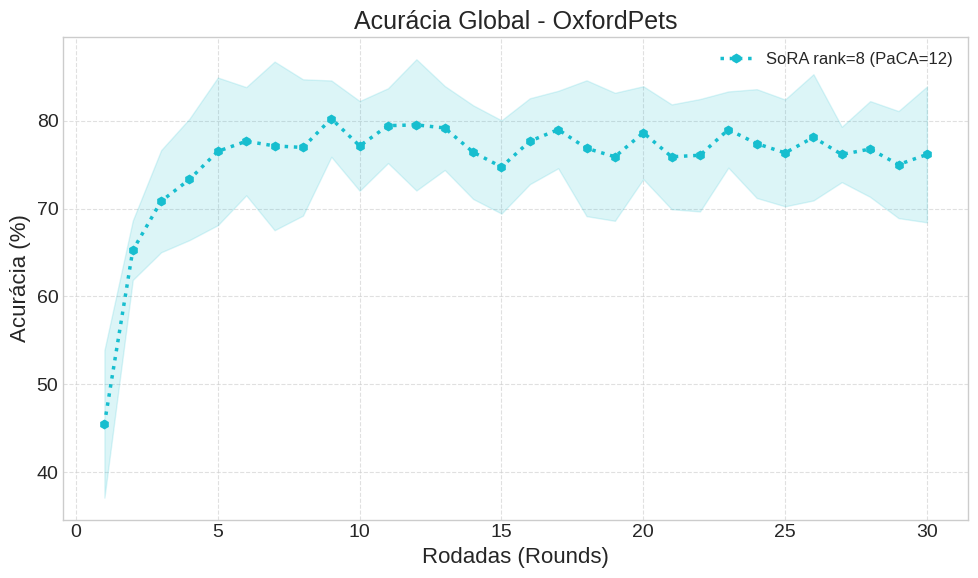

In [31]:
plt.figure(figsize=(10, 6))

plotou_algo = False
for label, dados, color, marker, ls in configs:
    if isinstance(dados, dict):
        eixo = range(1, len(dados['acc_mean']) + 1)
        plt.plot(eixo, dados['acc_mean'], label=label, color=color, linestyle=ls, marker=marker)
        plt.fill_between(eixo, 
                         dados['acc_mean'] - dados['acc_std'], 
                         dados['acc_mean'] + dados['acc_std'], color=color, alpha=0.15)
        plotou_algo = True

if plotou_algo:
    plt.title(f"Acurácia Global - {DATASET}")
    plt.xlabel("Rodadas (Rounds)")
    plt.ylabel("Acurácia (%)")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Nenhum dado encontrado para gerar o gráfico de Acurácia.")

### 2. Custo de Comunicação Acumulado (Megabytes)

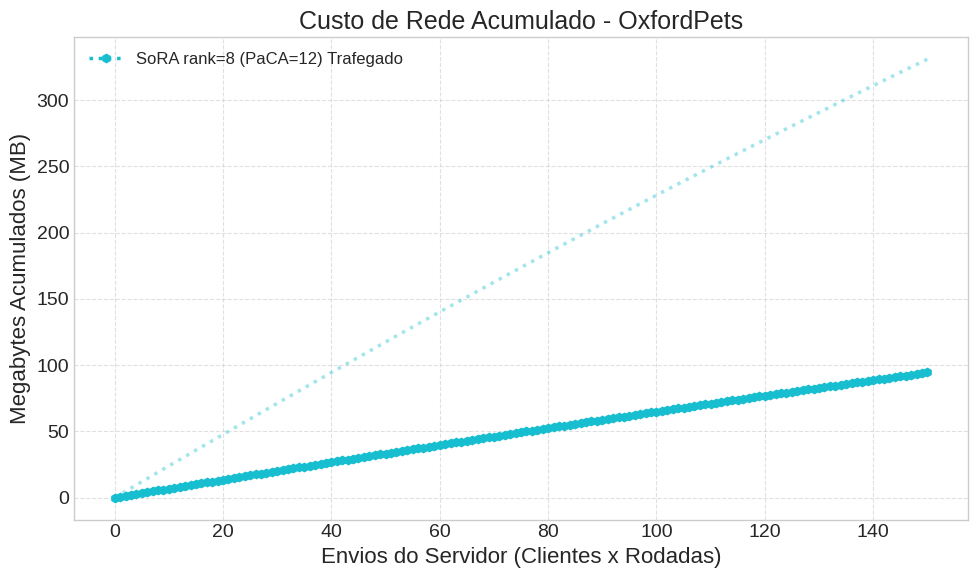

In [32]:
plt.figure(figsize=(10, 6))

plotou_algo = False
for label, dados, color, marker, ls in configs:
    if isinstance(dados, dict):
        eixo = range(len(dados['mb_mean']))
        
        # Linha pontilhada apagada mostrando o tamanho bruto daquela configuração
        plt.plot(eixo, dados['mb_bruto_mean'], color=color, linestyle=':', alpha=0.4)
        
        # Linha principal com quantização/SoRA
        plt.plot(eixo, dados['mb_mean'], label=f"{label} Trafegado", color=color, linestyle=ls, marker=marker)
        plt.fill_between(eixo, 
                         dados['mb_mean'] - dados['mb_std'], 
                         dados['mb_mean'] + dados['mb_std'], color=color, alpha=0.15)
        plotou_algo = True

if plotou_algo:
    plt.title(f"Custo de Rede Acumulado - {DATASET}")
    plt.xlabel("Envios do Servidor (Clientes x Rodadas)")
    plt.ylabel("Megabytes Acumulados (MB)")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Nenhum dado encontrado para gerar o gráfico de Comunicação.")

### 3. Latência de Treinamento (Tempo)

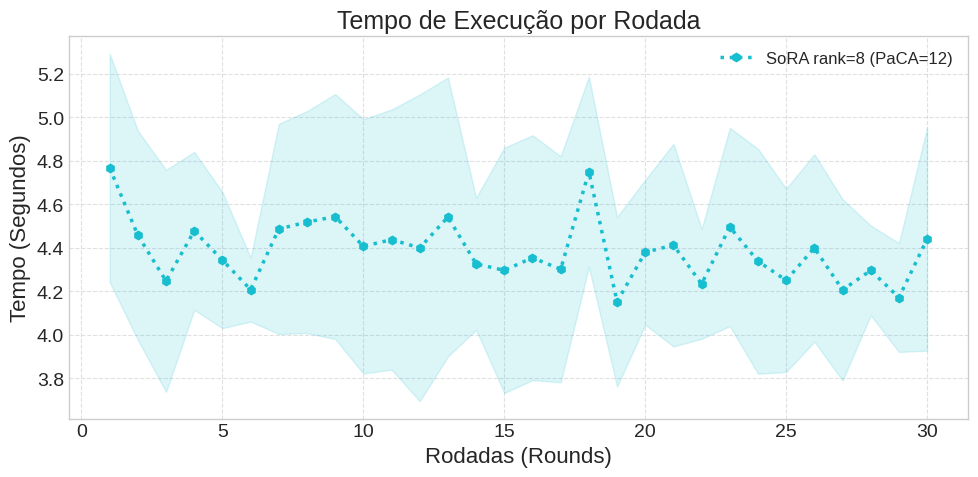

In [33]:
plt.figure(figsize=(10, 5))

plotou_algo = False
for label, dados, color, marker, ls in configs:
    if isinstance(dados, dict):
        eixo = range(1, len(dados['time_mean']) + 1)
        plt.plot(eixo, dados['time_mean'], label=label, color=color, linestyle=ls, marker=marker)
        plt.fill_between(eixo, 
                         dados['time_mean'] - dados['time_std'], 
                         dados['time_mean'] + dados['time_std'], color=color, alpha=0.15)
        plotou_algo = True

if plotou_algo:
    plt.title("Tempo de Execução por Rodada")
    plt.xlabel("Rodadas (Rounds)")
    plt.ylabel("Tempo (Segundos)")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Nenhum dado encontrado para gerar o gráfico de Latência.")

### 4. Tamanho do Modelo por Rodada e Evolução de Parâmetros

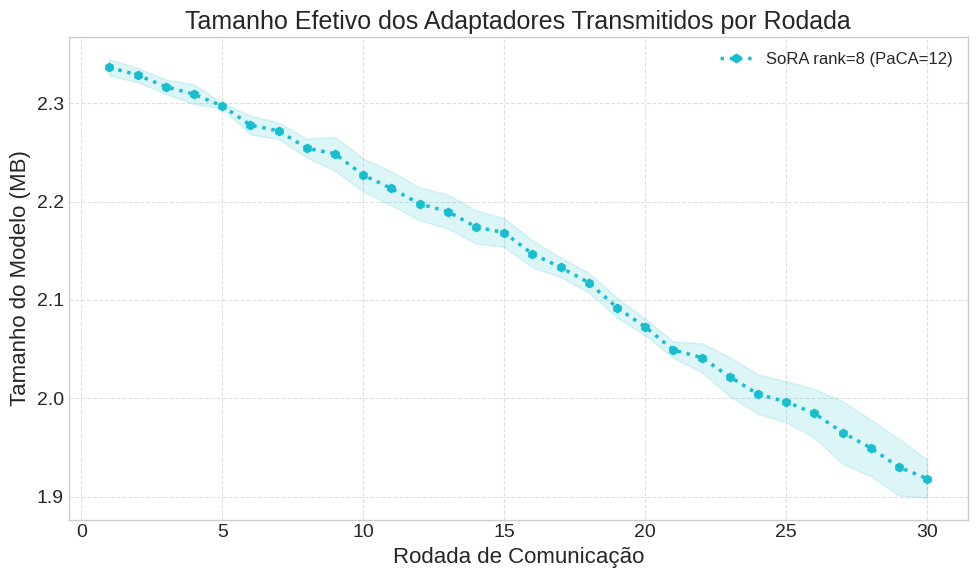

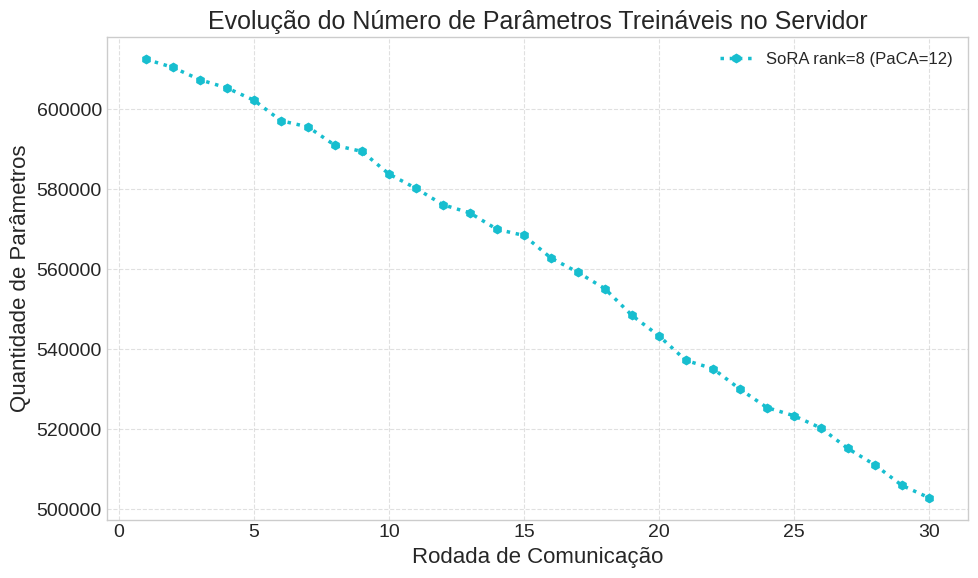

In [34]:
# --------------------------------------------------------------------------
# Gráfico 4.1: Tamanho Efetivo dos Adaptadores por Rodada (em MB)
# --------------------------------------------------------------------------
plt.figure(figsize=(10, 6))
plotou_algo = False

for label, dados, color, marker, ls in configs:
    if isinstance(dados, dict) and 'size_mb_mean' in dados:
        eixo = range(1, len(dados['size_mb_mean']) + 1)
        plt.plot(eixo, dados['size_mb_mean'], label=label, color=color, linestyle=ls, marker=marker)
        plt.fill_between(eixo, 
                         dados['size_mb_mean'] - dados['size_mb_std'], 
                         dados['size_mb_mean'] + dados['size_mb_std'], color=color, alpha=0.15)
        plotou_algo = True

if plotou_algo:
    plt.title("Tamanho Efetivo dos Adaptadores Transmitidos por Rodada")
    plt.xlabel("Rodada de Comunicação")
    plt.ylabel("Tamanho do Modelo (MB)")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Nenhum dado de tamanho de modelo encontrado.")

# --------------------------------------------------------------------------
# Gráfico 4.2: Evolução do Número de Parâmetros Treináveis
# --------------------------------------------------------------------------
plt.figure(figsize=(10, 6))
plotou_algo = False

for label, dados, color, marker, ls in configs:
    if isinstance(dados, dict) and 'params_mean' in dados:
        eixo = range(1, len(dados['params_mean']) + 1)
        plt.plot(eixo, dados['params_mean'], label=label, color=color, linestyle=ls, marker=marker)
        plotou_algo = True

if plotou_algo:
    plt.title("Evolução do Número de Parâmetros Treináveis no Servidor")
    plt.xlabel("Rodada de Comunicação")
    plt.ylabel("Quantidade de Parâmetros")
    plt.ticklabel_format(style='plain', axis='y') 
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Nenhum dado de parâmetro encontrado.")

In [35]:
import os
import glob
import numpy as np
import h5py
def load_strategy_results(dataset, strategy, paca=12, algo="FedALA", prune="withou_Prune", rank=8):
    if rank is not None:
        pattern = os.path.join(
            RESULTS_DIR,
            f"server_{dataset}_{strategy}_rank{rank}_paca{paca}_{prune}_{algo}_run*.h5"
        )
    else:
        pattern = os.path.join(
            RESULTS_DIR,
            f"server_{dataset}_{strategy}_paca{paca}_{prune}_{algo}_run*.h5"
        )
    files = glob.glob(pattern)
    
    if not files:
        print(f"⚠️ Nenhum arquivo de SERVIDOR encontrado para: {pattern}")
        return None
        
    print(f"✅ Encontrados {len(files)} arquivos de SERVIDOR para o padrão: {dataset}_{strategy}_paca{paca}_{prune}_{algo}")
    
    acc_runs, loss_runs, mb_runs, mb_bruto_runs, time_runs, params_runs, size_runs = [], [], [], [], [], [], []
    
    for f in files:
        with h5py.File(f, 'r') as hf:
            acc_runs.append(np.array(hf['rs_test_acc']))
            loss_runs.append(np.array(hf['rs_train_loss']))
            mb_runs.append(np.array(hf['sended_model_Mb']))
            mb_bruto_runs.append(np.array(hf['Sended_without_quant']))
            time_runs.append(np.array(hf['Round_time']))
            
            if 'Trainable_params' in hf:
                params_runs.append(np.array(hf['Trainable_params']))
            else:
                params_runs.append(np.zeros_like(np.array(hf['Round_time'])))
                
            if 'Model_size_per_round_Mb' in hf:
                size_runs.append(np.array(hf['Model_size_per_round_Mb']))
            else:
                size_runs.append(np.zeros_like(np.array(hf['Round_time'])))
            
    return {
        'acc_mean': np.mean(acc_runs, axis=0), 'acc_std': np.std(acc_runs, axis=0),
        'loss_mean': np.mean(loss_runs, axis=0), 'loss_std': np.std(loss_runs, axis=0),
        'mb_mean': np.mean(mb_runs, axis=0), 'mb_std': np.std(mb_runs, axis=0),
        'mb_bruto_mean': np.mean(mb_bruto_runs, axis=0), 'mb_bruto_std': np.std(mb_bruto_runs, axis=0),
        'time_mean': np.mean(time_runs, axis=0), 'time_std': np.std(time_runs, axis=0),
        'params_mean': np.mean(params_runs, axis=0), 'params_std': np.std(params_runs, axis=0),
        'size_mb_mean': np.mean(size_runs, axis=0), 'size_mb_std': np.std(size_runs, axis=0),
    }
def load_client_results(dataset, strategy, rank=8, algo="FedALA"):
    pattern = os.path.join(
        RESULTS_DIR,
        f"client_*_{dataset}_{strategy}_rank{rank}_paca*_{algo}_run*.h5"
    )
    files = glob.glob(pattern)
    if not files:
        print(f"⚠️ Nenhum arquivo de CLIENTE encontrado para: {pattern}")
        return None
    print(f"✅ Encontrados {len(files)} arquivos de CLIENTES para o padrão: {dataset}_{strategy}")
    
    global_acc_runs, global_loss_runs, ala_acc_runs, local_acc_runs, train_acc_runs = [], [], [], [], []
    for f in files:
        with h5py.File(f, 'r') as hf:
            global_acc_runs.append(np.array(hf['rs_global_acc']))
            global_loss_runs.append(np.array(hf['rs_global_loss']))
            if 'rs_ala_acc' in hf:
                ala_acc_runs.append(np.array(hf['rs_ala_acc']))
            local_acc_runs.append(np.array(hf['rs_local_acc']))
            train_acc_runs.append(np.array(hf['rs_train_acc']))
    return {
        'global_acc_mean': np.mean(global_acc_runs, axis=0), 'global_acc_std': np.std(global_acc_runs, axis=0),
        'global_loss_mean': np.mean(global_loss_runs, axis=0), 'global_loss_std': np.std(global_loss_runs, axis=0),
        'ala_acc_mean': np.mean(ala_acc_runs, axis=0) if ala_acc_runs else None,
        'local_acc_mean': np.mean(local_acc_runs, axis=0),
        'train_acc_mean': np.mean(train_acc_runs, axis=0)
    }


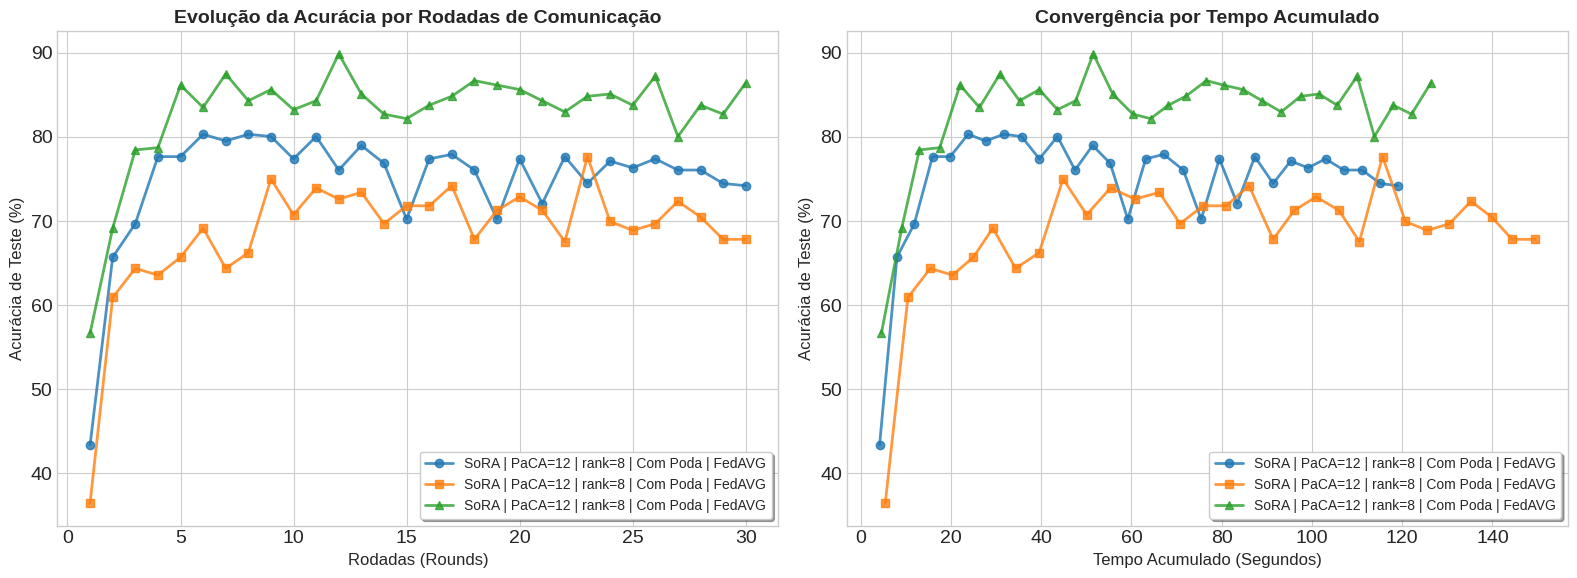

In [36]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt

# Caminho para a pasta de resultados
results_dir = f"../results/{EXP_NAME}"

# =====================================================
# CONFIGURAÇÃO DOS GRÁFICOS A SEREM PLOTADOS
# =====================================================
selected_configs = [
    ("paca9", "rank2"),
    ("paca12", "rank2"),
    ("paca12", "rank8"),
]

# Deixe vazio [] para plotar tudo
# selected_configs = []
# =====================================================

# Configuração visual dos gráficos
plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Títulos e labels
ax1.set_title("Evolução da Acurácia por Rodadas de Comunicação",
              fontsize=14, fontweight='bold')
ax1.set_xlabel("Rodadas (Rounds)", fontsize=12)
ax1.set_ylabel("Acurácia de Teste (%)", fontsize=12)

ax2.set_title("Convergência por Tempo Acumulado",
              fontsize=14, fontweight='bold')
ax2.set_xlabel("Tempo Acumulado (Segundos)", fontsize=12)
ax2.set_ylabel("Acurácia de Teste (%)", fontsize=12)

# Cores e marcadores para diferenciar as linhas
colors = plt.cm.tab10.colors
markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h']

file_idx = 0

for file in sorted(os.listdir(results_dir)):

    if not file.endswith(".h5"):
        continue

    filepath = os.path.join(results_dir, file)
    filename_parts = file.replace(".h5", "").split("_")

    # =====================================================
    # FILTRO POR PACA E RANK
    # =====================================================
    paca_parts = [p for p in filename_parts if p.startswith("paca")]
    rank_parts = [
        p for p in filename_parts
        if p.startswith("rank") and p[4:].isdigit()
    ]

    paca_token = paca_parts[0] if paca_parts else None
    rank_token = rank_parts[0] if rank_parts else None

    if selected_configs:
        if (paca_token, rank_token) not in selected_configs:
            continue
    # =====================================================

    try:
        dataset = filename_parts[0]

        strategy_parts = []
        for part in filename_parts[1:]:
            if part.startswith("paca") or part.startswith("rank"):
                break
            strategy_parts.append(part)

        raw_strategy = "_".join(strategy_parts).lower()

        if "sora" in raw_strategy:
            strategy = "SoRA"
        elif "lora" in raw_strategy:
            strategy = "LoRA"
        else:
            strategy = raw_strategy.upper()

        rank = rank_token.replace("rank", "") if rank_token else None
        paca = paca_token.replace("paca", "") if paca_token else "?"

        is_pruned = (
            "Sem Poda"
            if "withou_Prune" in file
            else "Com Poda"
        )

        algo = "FedALA" if "FedALA" in file else "FedAVG"

        label = f"{strategy} | PaCA={paca}"

        if rank:
            label += f" | rank={rank}"

        label += f" | {is_pruned} | {algo}"

    except Exception:
        label = file.replace(".h5", "")

    with h5py.File(filepath, 'r') as f:

        if 'rs_test_acc' not in f:
            continue

        acc = np.array(f['rs_test_acc'])
        rounds = np.arange(1, len(acc) + 1)

        if 'Round_time' in f:
            round_times = np.array(f['Round_time'])
            cumulative_time = np.cumsum(round_times)
        else:
            cumulative_time = rounds

    c = colors[file_idx % len(colors)]
    m = markers[file_idx % len(markers)]

    ax1.plot(
        rounds,
        acc,
        marker=m,
        color=c,
        linewidth=2,
        markersize=6,
        label=label,
        alpha=0.8
    )

    ax2.plot(
        cumulative_time,
        acc,
        marker=m,
        color=c,
        linewidth=2,
        markersize=6,
        label=label,
        alpha=0.8
    )

    file_idx += 1

ax1.legend(loc='lower right', fontsize=10, frameon=True, shadow=True)
ax2.legend(loc='lower right', fontsize=10, frameon=True, shadow=True)

plt.tight_layout()
plt.show()

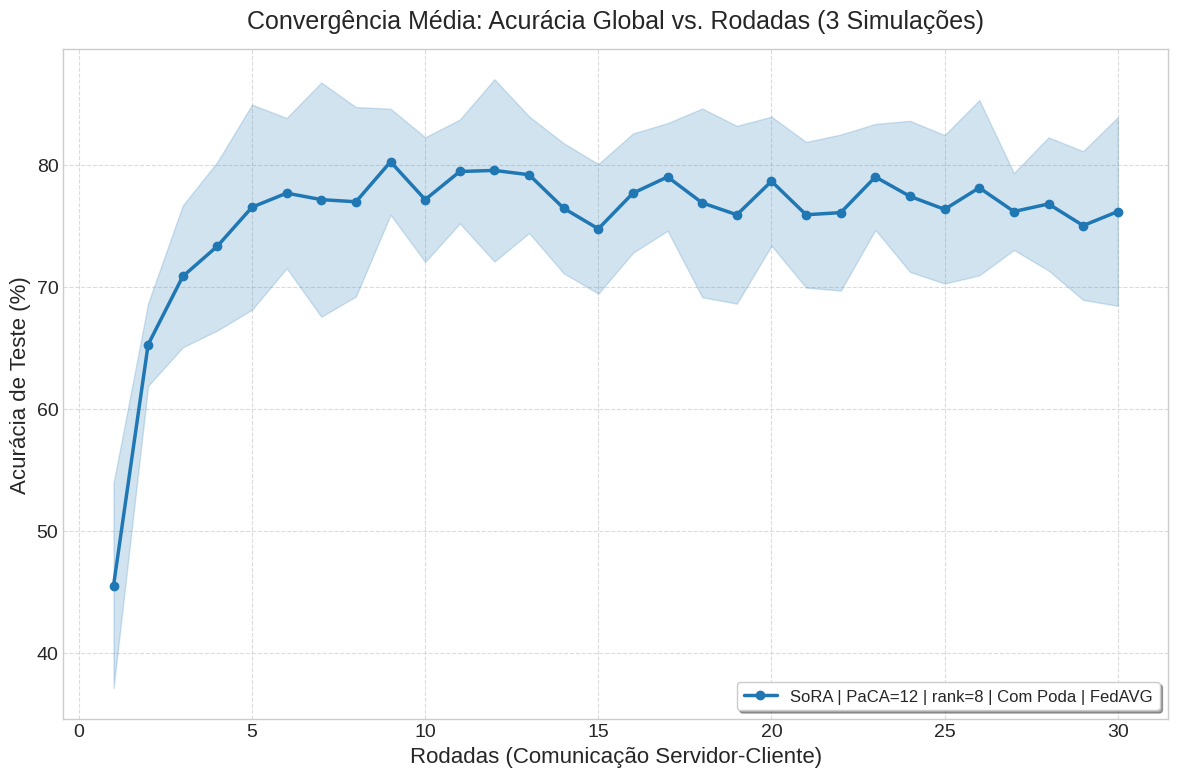

In [37]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import glob
from collections import defaultdict

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.size': 14,
    'axes.labelsize': 16,
    'axes.titlesize': 18,
    'legend.fontsize': 12,
    'lines.linewidth': 2.5
})

# Busca os arquivos globais do Servidor
RESULTS_DIR = f"../results/{EXP_NAME}/server_*.h5"
arquivos = glob.glob(RESULTS_DIR)

# =====================================================
# AGRUPADOR DE SIMULAÇÕES (RUNS)
# =====================================================
# Agrupa os arquivos ignorando a parte do "_runX"
experimentos = defaultdict(list)

for arquivo in arquivos:
    nome_base = arquivo.split('/')[-1].replace('.h5', '')
    
    # Tudo o que vier antes de "_run" é a identidade do experimento
    if "_run" in nome_base:
        nome_config = nome_base.split("_run")[0]
        experimentos[nome_config].append(arquivo)

# =====================================================
# PLOTAGEM
# =====================================================
plt.figure(figsize=(12, 8))
cores = plt.cm.tab10.colors
plot_idx = 0

for nome_config, arquivos_run in sorted(experimentos.items()):
    acc_matrix = []
    
    # --- Montagem dinâmica do Rótulo da Legenda ---
    is_pruned = "Sem Poda" if "withou_Prune" in nome_config else "Com Poda"
    algo = "FedALA" if "FedALA" in nome_config else "FedAVG"
    
    partes = nome_config.split('_')
    paca = next((p.replace("paca", "") for p in partes if p.startswith("paca")), "?")
    rank = next((p.replace("rank", "") for p in partes if p.startswith("rank") and p[4:].isdigit()), None)
    
    strategy_parts = []
    for p in partes[1:]:
        if p.startswith("rank") or p.startswith("paca"):
            break
        strategy_parts.append(p)
    raw_strategy = "_".join(strategy_parts).lower()
    strategy = "SoRA" if "sora" in raw_strategy else ("LoRA" if "lora" in raw_strategy else raw_strategy.upper())
    
    label = f"{strategy} | PaCA={paca}" + (f" | rank={rank}" if rank else "") + f" | {is_pruned} | {algo}"
    
    # --- Extração e Matemática ---
    for arquivo in arquivos_run:
        with h5py.File(arquivo, 'r') as hf:
            if 'rs_test_acc' in hf:
                acc_matrix.append(np.array(hf['rs_test_acc']))
                
    if not acc_matrix:
        continue
        
    # Converte para uma matriz numpy (Linhas=Runs, Colunas=Rodadas)
    acc_matrix = np.array(acc_matrix)
    
    # Calcula a Média e o Desvio Padrão ao longo das rodadas
    acc_media = np.mean(acc_matrix, axis=0)
    acc_std = np.std(acc_matrix, axis=0)
    
    # Eixo X (1, 2, 3 ... 30 rodadas)
    rodadas = np.arange(1, len(acc_media) + 1)
    
    # 1. Plota a linha grossa da média
    plt.plot(
        rodadas,
        acc_media,
        label=label,
        color=cores[plot_idx % len(cores)],
        marker='o',
        markersize=6
    )
    
    # 2. Plota a sombra transparente de desvio padrão
    plt.fill_between(
        rodadas,
        acc_media - acc_std,
        acc_media + acc_std,
        color=cores[plot_idx % len(cores)],
        alpha=0.2 # Deixa a cor 80% transparente
    )
    
    plot_idx += 1

plt.title("Convergência Média: Acurácia Global vs. Rodadas (3 Simulações)", pad=15)
plt.xlabel("Rodadas (Comunicação Servidor-Cliente)")
plt.ylabel("Acurácia de Teste (%)")

# Limita o X para mostrar divisões exatas (ex: de 5 em 5)
max_rounds = len(rodadas) if 'rodadas' in locals() else 30
plt.xticks(np.arange(0, max_rounds + 1, 5)) 

plt.legend(loc='lower right', frameon=True, shadow=True)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


/tmp/ipykernel_896776/774817838.py:204: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(


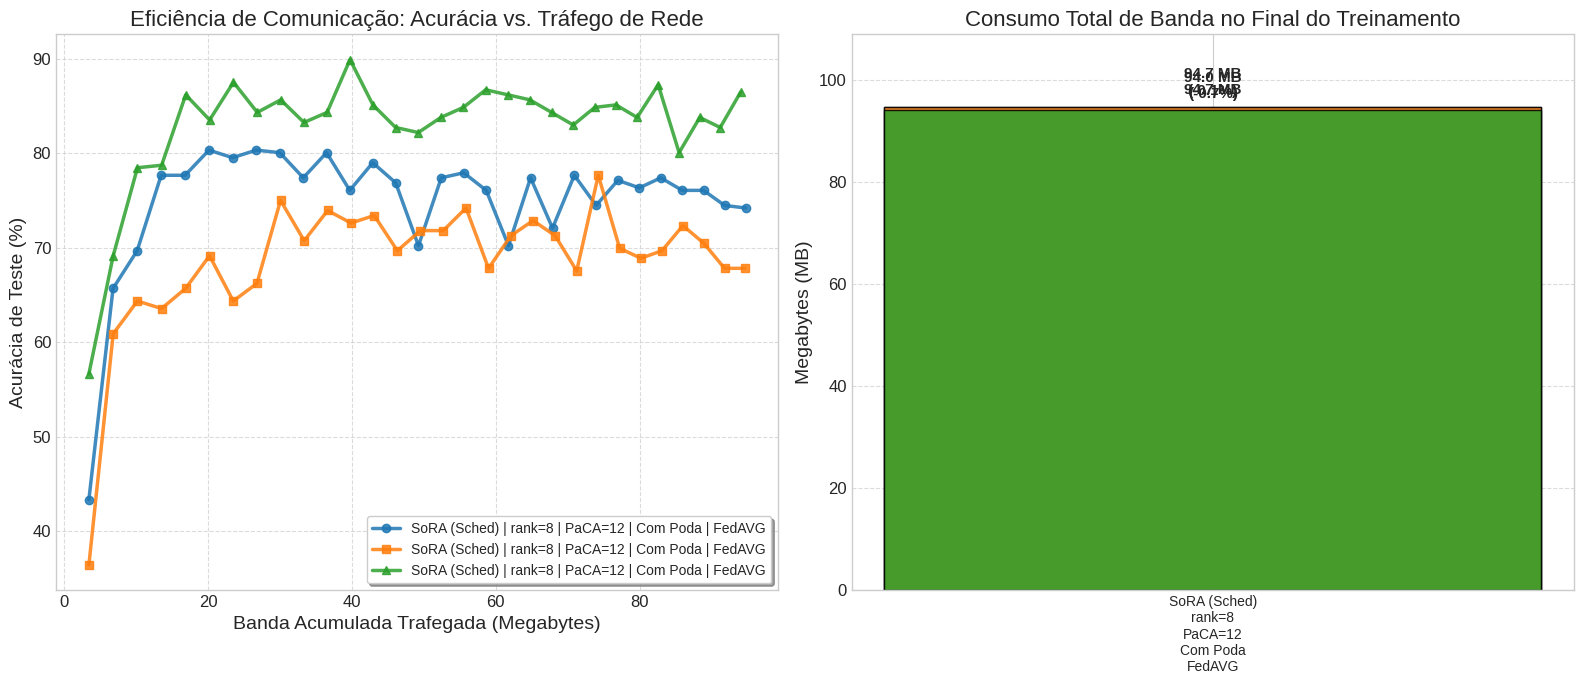

In [38]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import glob
import re

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'legend.fontsize': 11,
    'lines.linewidth': 2.5
})

# =====================================================
# CONFIGURAÇÃO DOS GRÁFICOS A SEREM PLOTADOS
# =====================================================
selected_configs = [
    # ("paca12", "rank2"),
    # ("paca12", "rank3"),
     ("paca12", "rank8"),
    ("paca12", "rank5"),
    # # ("paca12", "rank6"),
    # ("paca12", "rank7"),
    # ("paca12", "rank8"),
    
    # ("paca9", "rank2"),
    # ("paca9", "rank3"),
    # ("paca9", "rank4"),
    # ("paca9", "rank5"),
    # ("paca9", "rank6"),
    # ("paca9", "rank7"),
    # ("paca9", "rank8"),
    
    # ("paca12", "rank5"),
    # ("paca12", "rank6"),
    # ("paca12", "rank7"),
    # ("paca12", "rank8"),
    # ("paca9", "rank8"),
    # ("paca9", "rank2"),
]

# Deixe vazio [] para plotar tudo
# selected_configs = []
# =====================================================

# Função para formatar os nomes dinamicamente
def formatar_nomes(nome_arquivo):
    nome = nome_arquivo.replace('.h5', '').replace('Cifar100_', '').replace('OxfordPets_', '')

    if "sora_with_schedule" in nome:
        estr = "SoRA (Sched)"
    elif "sora_no_schedule" in nome:
        estr = "SoRA (No Sched)"
    elif "lora" in nome:
        estr = "LoRA"
    else:
        estr = "Padrão"

    match_rank = re.search(r'rank(\d+)', nome)
    rank = f"rank={match_rank.group(1)}" if match_rank else ""

    match_paca = re.search(r'paca(\d+)', nome)
    paca = f"PaCA={match_paca.group(1)}" if match_paca else ""

    poda = "Sem Poda" if ("withou_Prune" in nome or "lora" in nome) else "Com Poda"

    algo = "FedALA" if "FedALA" in nome else "FedAVG"

    partes = [p for p in [estr, rank, paca, poda, algo] if p]

    label_legenda = " | ".join(partes)
    label_eixo_x = "\n".join(partes)

    return label_legenda, label_eixo_x


RESULTS_DIR = f"../results/{EXP_NAME}/server_*.h5"
arquivos = glob.glob(RESULTS_DIR)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

cores = plt.cm.tab10.colors
marcadores = ['o', 's', '^', 'D', 'v', '<', '>']

nomes_estrategias_barras = []
consumo_total_mb = []
cores_barras = []

plot_idx = 0

for arquivo in sorted(arquivos):

    nome_base = arquivo.split('/')[-1]

    # =====================================================
    # FILTRO POR PACA E RANK
    # =====================================================
    nome_sem_ext = nome_base.replace('.h5', '')
    partes_nome = nome_sem_ext.split('_')

    paca_parts = [p for p in partes_nome if p.startswith("paca")]
    rank_parts = [
        p for p in partes_nome
        if p.startswith("rank") and p[4:].isdigit()
    ]

    paca_token = paca_parts[0] if paca_parts else None
    rank_token = rank_parts[0] if rank_parts else None

    if selected_configs:
        if (paca_token, rank_token) not in selected_configs:
            continue
    # =====================================================

    with h5py.File(arquivo, 'r') as hf:

        if 'rs_test_acc' not in hf or 'sended_model_Mb' not in hf:
            continue

        acuracia = np.array(hf.get('rs_test_acc'))

        banda_bruta = np.array(hf.get('sended_model_Mb'))

        if len(banda_bruta) > 0 and banda_bruta[0] == 0:
            banda_bruta = banda_bruta[1:]

        clientes_por_rodada = len(banda_bruta) // len(acuracia)

        if clientes_por_rodada > 0:
            banda_acumulada = banda_bruta[
                clientes_por_rodada - 1::clientes_por_rodada
            ]
        else:
            banda_acumulada = banda_bruta

        label_legenda, label_eixo_x = formatar_nomes(nome_base)

        cor = cores[plot_idx % len(cores)]
        marcador = marcadores[plot_idx % len(marcadores)]

        ax1.plot(
            banda_acumulada,
            acuracia,
            label=label_legenda,
            color=cor,
            marker=marcador,
            markersize=6,
            alpha=0.85
        )

        nomes_estrategias_barras.append(label_eixo_x)
        consumo_total_mb.append(banda_acumulada[-1])
        cores_barras.append(cor)

        plot_idx += 1

ax1.set_title("Eficiência de Comunicação: Acurácia vs. Tráfego de Rede")
ax1.set_xlabel("Banda Acumulada Trafegada (Megabytes)")
ax1.set_ylabel("Acurácia de Teste (%)")
ax1.legend(
    loc='lower right',
    frameon=True,
    shadow=True,
    fontsize=10
)
ax1.grid(True, linestyle='--', alpha=0.7)

barras = ax2.bar(
    nomes_estrategias_barras,
    consumo_total_mb,
    color=cores_barras,
    alpha=0.85,
    edgecolor='black'
)

if consumo_total_mb:

    max_mb = max(consumo_total_mb)

    for barra, mb in zip(barras, consumo_total_mb):

        altura = barra.get_height()
        economia_pct = ((max_mb - mb) / max_mb) * 100

        texto_label = f"{mb:.1f} MB"

        if economia_pct > 0:
            texto_label += f"\n(-{economia_pct:.1f}%)"

        ax2.text(
            barra.get_x() + barra.get_width()/2,
            altura + (max_mb * 0.02),
            texto_label,
            ha='center',
            va='bottom',
            fontsize=11,
            fontweight='bold'
        )

ax2.set_title("Consumo Total de Banda no Final do Treinamento")
ax2.set_ylabel("Megabytes (MB)")
ax2.set_xticklabels(
    nomes_estrategias_barras,
    rotation=0,
    ha='center',
    fontsize=10
)
ax2.grid(axis='y', linestyle='--', alpha=0.7)

if consumo_total_mb:
    ax2.set_ylim(0, max(consumo_total_mb) * 1.15)

plt.tight_layout()
plt.show()

/tmp/ipykernel_896776/3691583471.py:117: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='lower right', frameon=True, shadow=True)


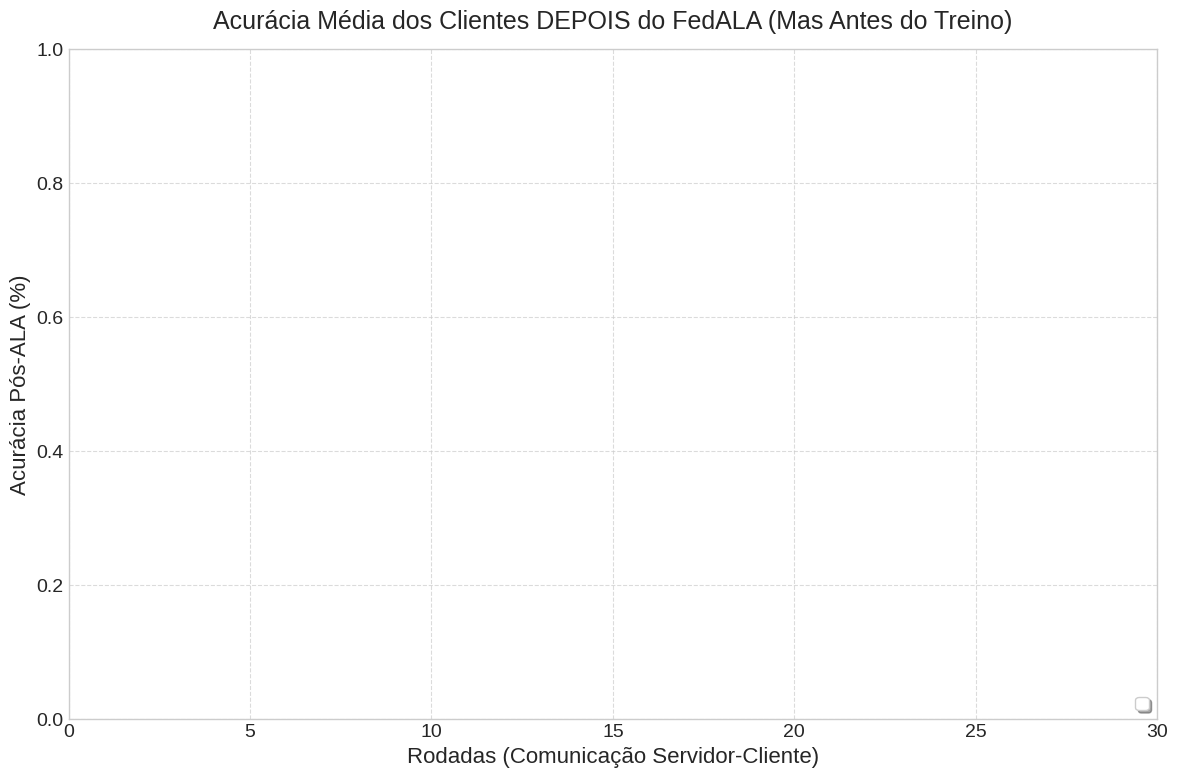

In [39]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import glob
import re
from collections import defaultdict

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.size': 14,
    'axes.labelsize': 16,
    'axes.titlesize': 18,
    'legend.fontsize': 12,
    'lines.linewidth': 2.5
})

# Busca na pasta interna dos CLIENTES
RESULTS_DIR = RESULTS_DIR
arquivos = glob.glob(RESULTS_DIR)

# =====================================================
# AGRUPADOR MULTI-NÍVEL (Config -> Run -> Clientes)
# =====================================================
# dicionário de dicionários: config -> run_id -> [arquivos]
experimentos = defaultdict(lambda: defaultdict(list))

for arquivo in arquivos:
    nome_base = arquivo.split('/')[-1].replace('.h5', '')
    
    # 1. Extrair de qual Simulação (Run) este arquivo é
    run_match = re.search(r'_run(\d+)', nome_base)
    if not run_match: 
        continue
    run_id = run_match.group(1)
    
    # 2. Criar um "Nome de Configuração" base, removendo paca, client e run
    # Ex: OxfordPets_sora_with_schedule_rank8_paca10_FedALA_client_2_run1
    # Vira: OxfordPets_sora_with_schedule_rank8_FedALA
    config_name = re.sub(r'_paca\d+', '', nome_base)
    config_name = re.sub(r'_client_\d+', '', config_name)
    config_name = re.sub(r'_run\d+', '', config_name)
    
    experimentos[config_name][run_id].append(arquivo)

# =====================================================
# PLOTAGEM
# =====================================================
plt.figure(figsize=(12, 8))
cores = plt.cm.tab10.colors
plot_idx = 0

for nome_config, runs_dict in sorted(experimentos.items()):
    runs_ala_acc = [] # Vai guardar a média final de CADA simulação (Run 1, 2, 3)
    
    # --- Montagem do Rótulo da Legenda ---
    algo = "FedALA" if "FedALA" in nome_config else "FedAVG"
    rank_match = re.search(r'rank(\d+)', nome_config)
    rank_str = f" | rank={rank_match.group(1)}" if rank_match else ""
    
    strategy = "SoRA" if "sora" in nome_config.lower() else "LoRA"
    label = f"Média Clientes: {strategy}{rank_str} | {algo}"
    
    # --- Processa CADA Simulação (Run) separadamente ---
    for run_id, client_files in runs_dict.items():
        client_ala_accs = []
        
        # Puxa o dado 'rs_ala_acc' dos 5 clientes desta simulação
        for f in client_files:
            with h5py.File(f, 'r') as hf:
                if 'rs_ala_acc' in hf:
                    arr = np.array(hf['rs_ala_acc'])
                    if len(arr) > 0:
                        client_ala_accs.append(arr)
        
        # Tira a média dos 5 clientes para representar ESTA simulação
        if client_ala_accs:
            # Garante que todos os clientes tenham o mesmo número de rodadas salvas
            min_len = min([len(a) for a in client_ala_accs])
            client_ala_accs_cortado = [a[:min_len] for a in client_ala_accs]
            
            run_mean = np.mean(client_ala_accs_cortado, axis=0)
            runs_ala_acc.append(run_mean)
            
    if not runs_ala_acc:
        continue
        
    # --- Processa a Média e Desvio Padrão ENTRE as Simulações (Runs) ---
    min_len_runs = min([len(r) for r in runs_ala_acc])
    runs_ala_acc_cortado = [r[:min_len_runs] for r in runs_ala_acc]
    
    acc_media = np.mean(runs_ala_acc_cortado, axis=0)
    acc_std = np.std(runs_ala_acc_cortado, axis=0)
    
    rodadas = np.arange(1, len(acc_media) + 1)
    
    # Plotar linha e sombra
    plt.plot(
        rodadas, acc_media, 
        label=label, color=cores[plot_idx % len(cores)], 
        marker='s', markersize=6, linewidth=2.5
    )
    plt.fill_between(
        rodadas, acc_media - acc_std, acc_media + acc_std, 
        color=cores[plot_idx % len(cores)], alpha=0.2
    )
    
    plot_idx += 1

plt.title("Acurácia Média dos Clientes DEPOIS do FedALA (Mas Antes do Treino)", pad=15)
plt.xlabel("Rodadas (Comunicação Servidor-Cliente)")
plt.ylabel("Acurácia Pós-ALA (%)")

# Ajuste do eixo X para rodadas
max_rounds = len(rodadas) if 'rodadas' in locals() else 30
plt.xticks(np.arange(0, max_rounds + 1, 5)) 

plt.legend(loc='lower right', frameon=True, shadow=True)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
